# Analyze imported BBP simulation campaigns

In [20]:
from bluepysnap import Circuit, Simulation
from entitysdk import models
from entitysdk.client import Client
from entitysdk.staging.circuit import stage_circuit
from entitysdk.staging.simulation_result import stage_simulation, stage_simulation_result
from obi_auth import get_token
from obi_notebook import get_entities
from obi_notebook.get_environment import get_environment
from obi_notebook.get_projects import get_projects
from pathlib import Path
from tqdm import tqdm

## Campaign selection and download

#### Get authentication token and choose a project context

In [2]:
token = get_token(environment=get_environment(), auth_mode="daf")
project_context = get_projects(token=token)

Dropdown(description='Select:', options=(('My first project', {'id': '7a411785-6895-4839-aaa2-d9f76e09875a', '…

#### Initialize the client with the token and project context

In [3]:
client = Client(environment=get_environment(), project_context=project_context, token_manager=token)

#### Select a BBP SimulationCampaign

Either by:
1. Specifying SimulationCampaign IDs
2. Selecting from the widget

For example, select one of the following BBP campaigns:
- `BBP-SM-recalib`
- `BBP-SM-whisker-scan`
- `BBP-SM-whisker-soma`


In [4]:
# Optional: Download using unique ID
entity_ID = "<SIMULATION-CAMPAIGN-ID>"  # <<< FILL IN A UNIQUE SIMULATION CAMPAIGN IDENTIFIER HERE

if entity_ID != "<SIMULATION-CAMPAIGN-ID>":
    simulation_campaign_id = entity_ID
else:
# Alternative: Select from a table of entities
    simulation_campaign_id = []
    simulation_campaign_id = get_entities.get_entities(
        "simulation-campaign", token, simulation_campaign_id,
        project_context=project_context,
        multi_select=False,
        page_size=1000,
        add_columns=["scan_parameters"],
    )

Output()

In [5]:
if isinstance(simulation_campaign_id, list):
    assert len(simulation_campaign_id) == 1, "ERROR: Only a single campaign ID expected!"
    simulation_campaign_id = simulation_campaign_id[0]

In [6]:
# Load campaign entity and show details (optional)
show_details = False

simulation_campaign = client.get_entity(entity_id=simulation_campaign_id, entity_type=models.SimulationCampaign)
circuit = client.get_entity(entity_id=simulation_campaign.entity_id, entity_type=models.Circuit)
print(f"Loaded campaign '{simulation_campaign.name}' (ID {simulation_campaign.id}):\n")
print(simulation_campaign.description)
print()
print(f"Circuit: '{circuit.name}' (ID {circuit.id})\n")
print(f"Number of simulations: {len(simulation_campaign.simulations)}\n")
print("Scan parameters:")
print("\n".join([f"  {k}: {v}" for k, v in simulation_campaign.scan_parameters.items()]))

if show_details:
    print("\nList of simulations:")
    for sim in simulation_campaign.simulations:
        sim = client.get_entity(entity_id=sim.id, entity_type=models.Simulation)  # To get assets!!
        print(f"  Simulation '{sim.name}' (ID {sim.id}): ")
        print(f"    {sim.scan_parameters}")

Loaded campaign 'BBP-SM-whisker-scan' (ID 4dbc44a3-90ea-4e3b-a53e-62417635e91d):

BBP campaign consisting of 72 simulations of the nbS1-O1-SM (Schneider-Mizell) circuit with whisker flick stimulation on VPM fibers, scanned over different values of calcium, Ornstein-Uhlenbeck std to mean ratio R_OU, in-vivo firing rate proportion P_FR, and percentage of VPM fibers. Related publication: Isbister et al., 2025 (DOI: 10.7554/eLife.99693.2)

Circuit: 'nbS1-O1-SM' (ID 28049bf1-2082-4fa5-a6d6-540497da6d54)

Number of simulations: 72

Scan parameters:
  ca: [1.05, 1.1]
  vpm_pct: [5.0, 10.0, 15.0]
  depol_stdev_mean_ratio: [0.2, 0.3, 0.4]
  desired_connected_proportion_of_invivo_frs: [0.1, 0.3, 0.5, 0.7]


#### Stage the campaign together with the corresponding circuit
If the entities have been staged before, they will be loaded from cache instead of staging them again.

In [7]:
CIRCUIT_STAGING_ROOT = Path("/home/shared_data/entity_cache/sonata_circuit")
CAMPAIGN_STAGING_ROOT = Path("./staged_simulation_campaigns")

In [13]:
def stage_campaign_circuit(simulation_campaign_id, output_root):
    """Stage the circuit of a simulation campaign, incl. caching."""
    # Get circuit ID from simulation campaign
    simulation_campaign = client.get_entity(entity_type=models.SimulationCampaign, entity_id=simulation_campaign_id)
    circuit_id = str(simulation_campaign.entity_id)
    circuit_entity = client.get_entity(entity_type=models.Circuit, entity_id=circuit_id)

    # Stage circuit or use from cache
    output_dir = Path(output_root).resolve() / circuit_id
    if output_dir.exists():
        print(f"INFO: Using cached circuit '{circuit_entity.name}'")
        circuit_config_path = output_dir / "circuit_config.json"
    else:
        circuit_config_path = stage_circuit(
            client=client,
            model=circuit_entity,
            output_dir=output_dir,
            max_concurrent=4,
        )
    assert circuit_config_path.is_file(), "ERROR: Circuit staging error - clear cache and retry!"
    print(f"INFO: Staged circuit '{circuit_entity.name}' at {circuit_config_path}")

    return circuit_config_path

def stage_sim_campaign(simulation_campaign_id, output_root, circuit_config_path):
    """Stage the simulation campaign w/o circuit, incl. caching."""
    simulation_campaign = client.get_entity(entity_type=models.SimulationCampaign, entity_id=simulation_campaign_id)
    campaign_output_dir = Path(output_root).resolve() / str(simulation_campaign_id)

    # Stage individual simulations and results
    num_cached = 0
    num_staged = 0
    simulation_config_paths = []
    for simulation in tqdm(simulation_campaign.simulations):
        # IMPORTANT: The order of simulations returned by simulation_campaign.simulations is not necessarily ordered!!

        simulation = client.get_entity(entity_id=simulation.id, entity_type=models.Simulation)  # Required to get assets!!

        # Stage simulation + result or use from cache
        sim_dir = simulation.name.replace(" ", "_").lower()
        output_dir = campaign_output_dir / sim_dir
        if output_dir.exists():
            num_cached += 1
            # print(f"INFO: Using cached simulation '{simulation.name}'")
            simulation_config_path = output_dir / "simulation_config.json"
        else:
            # Stage simulation
            num_staged += 1
            simulation_config_path = stage_simulation(
                client=client,
                model=simulation,
                output_dir=output_dir,
                circuit_config_path=circuit_config_path,
            )

            # Get simulation execution and stage simulation result
            simulation_executions = client.search_entity(
                entity_type=models.SimulationExecution,
                query={"used__id": simulation.id}
            ).all()

            if len(simulation_executions) == 0:
                print(f"WARNING: No SimulationExecution/Result found for Simulation ID {simulation.id}")
            else:
                simulation_execution = simulation_executions[0]
                simulation_result_id = simulation_execution.generated[0].id
                simulation_result = client.get_entity(entity_type=models.SimulationResult, entity_id=simulation_result_id)

                _ = stage_simulation_result(
                    client=client,
                    model=simulation_result,
                    output_dir=output_dir,
                    simulation_config_file=simulation_config_path,
                )
        
        assert simulation_config_path.is_file(), "ERROR: Simulation staging error - clear cache and retry!"
        # print(f"INFO: Staged simulation '{simulation.name}' at {simulation_config_path}")

        simulation_config_paths.append(str(simulation_config_path))

    # Stage campaign summary
    for asset in simulation_campaign.assets:
        if asset.label == "campaign_summary":
            client.download_file(
                asset_id=asset.id,
                entity_id=simulation_campaign_id,
                entity_type=models.SimulationCampaign,
                output_path=campaign_output_dir,
            )
            break

    print(f"INFO: Staged campaign '{simulation_campaign.name}' with {len(simulation_config_paths)} simulation(s) ({num_staged} downloaded, {num_cached} cached) at {campaign_output_dir}")

    return simulation_config_paths


In [9]:
staged_circuit_config = stage_campaign_circuit(
    simulation_campaign_id=simulation_campaign.id,
    output_root=CIRCUIT_STAGING_ROOT,
)

INFO: Using cached circuit 'nbS1-O1-SM'
INFO: Staged circuit 'nbS1-O1-SM' at /home/shared_data/entity_cache/sonata_circuit/28049bf1-2082-4fa5-a6d6-540497da6d54/circuit_config.json


In [17]:
staged_sim_configs = stage_sim_campaign(
    simulation_campaign_id=simulation_campaign.id,
    output_root=CAMPAIGN_STAGING_ROOT,
    circuit_config_path=staged_circuit_config
)

100%|██████████| 72/72 [00:01<00:00, 36.71it/s]


INFO: Staged campaign 'BBP-SM-whisker-scan' with 72 simulation(s) (0 downloaded, 72 cached) at /home/jovyan/bbp_simulation_campaign_analysis/staged_simulation_campaigns/4dbc44a3-90ea-4e3b-a53e-62417635e91d


## Campaign analysis

#### Plot spikes

In [18]:
def plot_spikes(simulation_config_paths):
    for simulation_config_path in simulation_config_paths:
        # print(f"Processing simulation config path: {simulation_config_path}")
        
        # Plot and print the spikes
        snap_simulation = Simulation(simulation_config_path)
        spikes = snap_simulation.spikes
        spikes.filter().raster()

        # print(spikes.population_names)
        # for population in spikes.population_names:
        #     population_spikes = spikes[population]
        #     print(population_spikes.get())


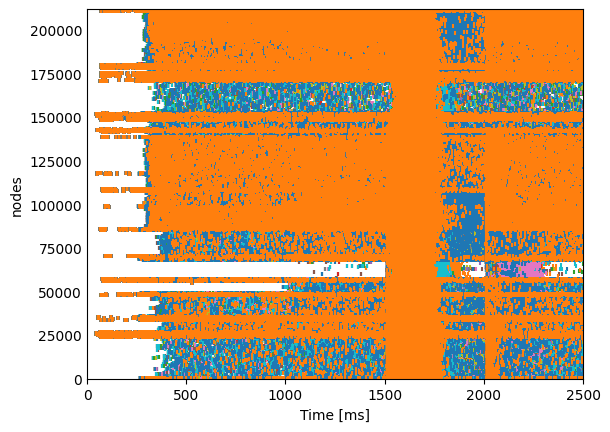

In [21]:
plot_spikes(staged_sim_configs)